# Comparaison d'algorithmes MCMC
**Métriques** : CPU time · Inferential error · Monte Carlo error  
**Cible** : N(0, I_d) en dimension d = 11  
**Algorithmes** : Random-Walk Metropolis · MALA · HMC · Gibbs Sampling


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import statsmodels.api as sm
import time
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
rng = np.random.default_rng(42)


## 1 · Configuration & distribution cible

In [2]:
d       = 11          # dimension (identique au notebook de référence)
N       = 10_000      # longueur de la chaîne
BURNIN  = 1_000       # burn-in (identique au notebook de référence)
N_REP   = 10          # répétitions pour moyenner les métriques

# ── Cible : N(0, I_d) ──────────────────────────────────────────────────────
def log_target(x):
    """Log-densité de N(0, I_d) — proportionnelle suffit."""
    return -0.5 * np.sum(x**2)

def grad_log_target(x):
    """Gradient du log de la cible (utilisé par MALA et HMC)."""
    return -x


## 2 · Implémentation des algorithmes

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# 2.1  Random-Walk Metropolis (RWM) — algorithme de référence
# ─────────────────────────────────────────────────────────────────────────────
def run_rwm(N, d, sigma=0.8, x0=None):
    """
    Reproduit exactement le notebook de référence.
    sigma : écart-type de la proposition gaussienne.
    """
    if x0 is None:
        x0 = np.linspace(-50, 50, d)   # même initialisation que le notebook
    chain = np.empty((N, d))
    chain[0] = x0
    acc = 0
    for n in range(1, N):
        prop = chain[n-1] + sigma * np.random.randn(d)
        log_u = np.log(np.random.rand())
        if log_u < log_target(prop) - log_target(chain[n-1]):
            chain[n] = prop
            acc += 1
        else:
            chain[n] = chain[n-1]
    return chain, acc / N


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# 2.2  MALA — Metropolis-Adjusted Langevin Algorithm
# ─────────────────────────────────────────────────────────────────────────────
def run_mala(N, d, step=0.5, x0=None):
    """
    Proposition biaisée vers le gradient : x' = x + (h²/2)∇log π(x) + h·ε
    Correction MH pour garantir π comme loi stationnaire.
    """
    if x0 is None:
        x0 = np.linspace(-50, 50, d)
    chain = np.empty((N, d))
    chain[0] = x0
    acc = 0
    h2 = step**2
    for n in range(1, N):
        x   = chain[n-1]
        g   = grad_log_target(x)
        mu  = x + 0.5 * h2 * g                      # moyenne de la proposition
        prop = mu + step * np.random.randn(d)

        # log-noyau de proposition (MH asymétrique → correction nécessaire)
        g_prop   = grad_log_target(prop)
        mu_back  = prop + 0.5 * h2 * g_prop
        log_q_fwd  = -0.5 * np.sum((prop - mu)**2)  / h2
        log_q_back = -0.5 * np.sum((x   - mu_back)**2) / h2

        log_alpha = (log_target(prop) + log_q_back
                   - log_target(x)   - log_q_fwd)
        if np.log(np.random.rand()) < log_alpha:
            chain[n] = prop
            acc += 1
        else:
            chain[n] = x
    return chain, acc / N


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# 2.3  HMC — Hamiltonian Monte Carlo
# ─────────────────────────────────────────────────────────────────────────────
def run_hmc(N, d, epsilon=0.2, L=10, x0=None):
    """
    Dynamique hamiltonienne discrétisée (leapfrog L pas de taille epsilon).
    Masse M = I_d.
    """
    if x0 is None:
        x0 = np.linspace(-50, 50, d)
    chain = np.empty((N, d))
    chain[0] = x0
    acc = 0
    for n in range(1, N):
        q = chain[n-1].copy()
        p = np.random.randn(d)               # tirage du moment
        H_cur = -log_target(q) + 0.5 * np.sum(p**2)

        # ── Leapfrog ─────────────────────────────────────────────────────────
        q_new, p_new = q.copy(), p.copy()
        p_new += 0.5 * epsilon * grad_log_target(q_new)
        for _ in range(L):
            q_new += epsilon * p_new
            p_new += epsilon * grad_log_target(q_new)
        p_new += 0.5 * epsilon * grad_log_target(q_new)
        # ─────────────────────────────────────────────────────────────────────

        H_prop = -log_target(q_new) + 0.5 * np.sum(p_new**2)
        if np.log(np.random.rand()) < H_cur - H_prop:   # MH accept/reject
            chain[n] = q_new
            acc += 1
        else:
            chain[n] = q
    return chain, acc / N


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# 2.4  Gibbs Sampling (coordonnée par coordonnée)
# ─────────────────────────────────────────────────────────────────────────────
def run_gibbs(N, d, x0=None):
    """
    Pour N(0,I_d) les conditionnelles sont N(0,1) → tirage exact.
    Pas de correction MH nécessaire (taux d'acceptation = 1 par construction).
    """
    if x0 is None:
        x0 = np.linspace(-50, 50, d)
    chain = np.empty((N, d))
    chain[0] = x0.copy()
    for n in range(1, N):
        x = chain[n-1].copy()
        for j in range(d):
            x[j] = np.random.randn()      # conditionnelle exacte : N(0,1)
        chain[n] = x
    return chain, 1.0                     # acceptation toujours 1


## 3 · Définitions des métriques

| Métrique | Définition | Interprétation |
|---|---|---|
| **CPU time** | Temps wall-clock pour générer N échantillons (s) | Coût computationnel |
| **Inferential error** | `‖E[X] - 0‖ / d` — biais moyen absolu post burn-in | Qualité de l'estimation bayésienne |
| **Monte Carlo error** | `mean(std(X_j)) / sqrt(ESS)` — erreur standard MC moyenne | Précision statistique des estimateurs |

L'**ESS** (Effective Sample Size) est estimé via l'ACF : ESS = N / (1 + 2 Σ ρ_k).


In [7]:
def ess_from_chain(chain_post):
    """ESS moyen sur les d composantes (méthode ACF tronquée)."""
    n, d = chain_post.shape
    ess_list = []
    for j in range(d):
        acf = sm.tsa.acf(chain_post[:, j], nlags=min(500, n//2), fft=True)
        # On tronque à la première ACF négative (règle de Geyer)
        cut = next((k for k in range(1, len(acf)) if acf[k] < 0), len(acf))
        ess = n / max(1, 1 + 2 * np.sum(acf[1:cut]))
        ess_list.append(min(ess, n))   # ESS ≤ N
    return np.mean(ess_list)

def inferential_error(chain_post):
    """Biais moyen absolu de l'estimateur de la moyenne (vraie valeur = 0)."""
    return np.mean(np.abs(chain_post.mean(axis=0)))

def mc_error(chain_post):
    """Erreur standard Monte Carlo : std_j / sqrt(ESS)."""
    ess = ess_from_chain(chain_post)
    return np.mean(chain_post.std(axis=0)) / np.sqrt(max(ess, 1))


## 4 · Benchmark

In [8]:
algorithms = {
    'RWM'   : lambda: run_rwm(N, d),
    'MALA'  : lambda: run_mala(N, d),
    'HMC'   : lambda: run_hmc(N, d),
    'Gibbs' : lambda: run_gibbs(N, d),
}

results = {name: {'cpu': [], 'inf_err': [], 'mc_err': [], 'acc': []}
           for name in algorithms}

print(f"Benchmark — {N_REP} répétitions × {N} itérations × d={d}")
print("─" * 60)

for rep in range(N_REP):
    for name, fn in algorithms.items():
        np.random.seed(rep)
        t0 = time.perf_counter()
        chain, acc_rate = fn()
        elapsed = time.perf_counter() - t0

        post = chain[BURNIN:]
        results[name]['cpu'].append(elapsed)
        results[name]['acc'].append(acc_rate)
        results[name]['inf_err'].append(inferential_error(post))
        results[name]['mc_err'].append(mc_error(post))

    print(f"  répétition {rep+1}/{N_REP} ✓")

print("\nDone.")


Benchmark — 10 répétitions × 10000 itérations × d=11
────────────────────────────────────────────────────────────
  répétition 1/10 ✓
  répétition 2/10 ✓
  répétition 3/10 ✓
  répétition 4/10 ✓
  répétition 5/10 ✓
  répétition 6/10 ✓
  répétition 7/10 ✓
  répétition 8/10 ✓
  répétition 9/10 ✓
  répétition 10/10 ✓

Done.


In [9]:
import pandas as pd

summary = {}
for name, m in results.items():
    summary[name] = {
        'CPU time (s)'           : f"{np.mean(m['cpu']):.3f} ± {np.std(m['cpu']):.3f}",
        'Inferential error'      : f"{np.mean(m['inf_err']):.4f} ± {np.std(m['inf_err']):.4f}",
        'Monte Carlo error'      : f"{np.mean(m['mc_err']):.4f} ± {np.std(m['mc_err']):.4f}",
        'Acceptance rate'        : f"{np.mean(m['acc']):.2%}",
    }

df_summary = pd.DataFrame(summary).T
print(df_summary.to_string())


        CPU time (s) Inferential error Monte Carlo error Acceptance rate
RWM    0.153 ± 0.024   0.0515 ± 0.0102   0.0623 ± 0.0016          21.95%
MALA   0.293 ± 0.020   0.0287 ± 0.0050   0.0412 ± 0.0008          95.90%
HMC    0.635 ± 0.030   0.0067 ± 0.0012   0.0099 ± 0.0000          70.63%
Gibbs  0.087 ± 0.011   0.0080 ± 0.0018   0.0106 ± 0.0001         100.00%


## 5 · Visualisations comparatives

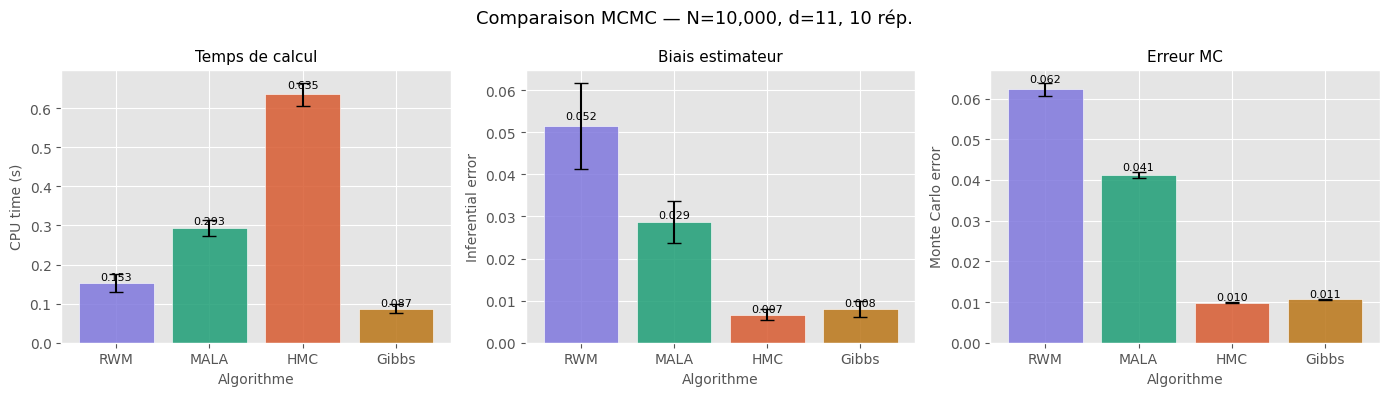

In [10]:
# ── 5.1 Barplots des 3 métriques ────────────────────────────────────────────
names  = list(results.keys())
colors = ['#7F77DD', '#1D9E75', '#D85A30', '#BA7517']
metrics = [
    ('cpu',     'CPU time (s)',        'Temps de calcul'),
    ('inf_err', 'Inferential error',   'Biais estimateur'),
    ('mc_err',  'Monte Carlo error',   'Erreur MC'),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(f'Comparaison MCMC — N={N:,}, d={d}, {N_REP} rép.', fontsize=13)

for ax, (key, ylabel, title) in zip(axes, metrics):
    means = [np.mean(results[n][key]) for n in names]
    stds  = [np.std(results[n][key])  for n in names]
    bars  = ax.bar(names, means, yerr=stds, color=colors,
                   capsize=5, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xlabel('Algorithme', fontsize=10)
    # Valeurs sur les barres
    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                f'{m:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('benchmark_barplots.png', dpi=150, bbox_inches='tight')
plt.show()


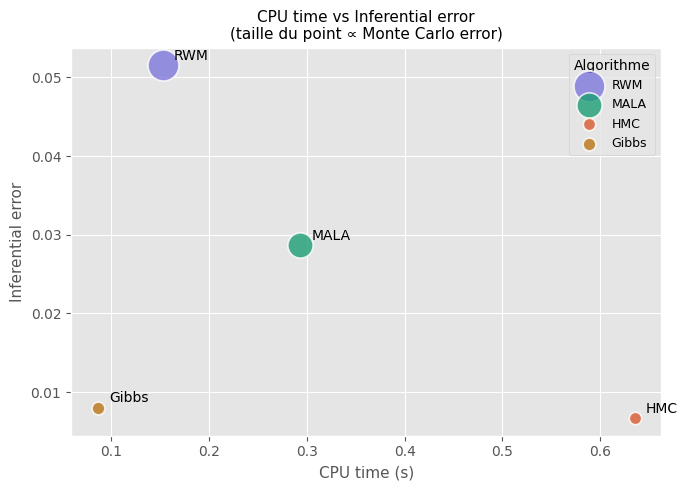

→ L'algorithme idéal est en bas à gauche avec un petit point.


In [11]:
# ── 5.2 Scatter : CPU time vs Inferential error (taille = MC error) ─────────
fig, ax = plt.subplots(figsize=(7, 5))

for i, name in enumerate(names):
    x   = np.mean(results[name]['cpu'])
    y   = np.mean(results[name]['inf_err'])
    sz  = np.mean(results[name]['mc_err']) * 8000   # taille ∝ MC error
    ax.scatter(x, y, s=sz, color=colors[i], alpha=0.8,
               edgecolors='white', linewidths=1.2, label=name, zorder=3)
    ax.annotate(name, (x, y), textcoords='offset points',
                xytext=(8, 4), fontsize=10)

ax.set_xlabel('CPU time (s)', fontsize=11)
ax.set_ylabel('Inferential error', fontsize=11)
ax.set_title('CPU time vs Inferential error\n(taille du point ∝ Monte Carlo error)', fontsize=11)
ax.legend(title='Algorithme', fontsize=9)
plt.tight_layout()
plt.savefig('benchmark_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("→ L'algorithme idéal est en bas à gauche avec un petit point.")


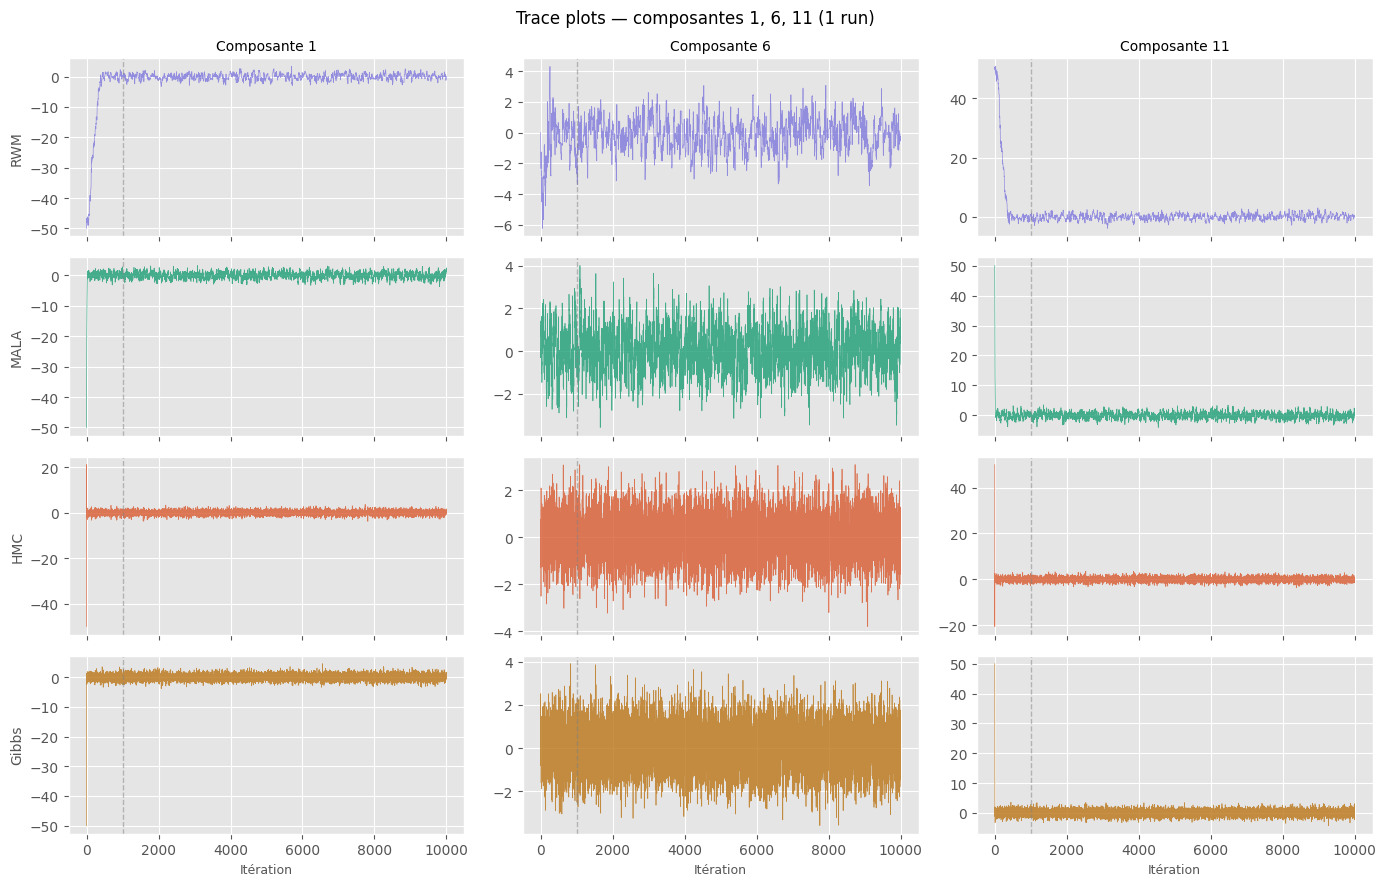

In [12]:
# ── 5.3 Trace plots (1 run) pour les 4 algorithmes ──────────────────────────
np.random.seed(0)
traces = {}
for name, fn in algorithms.items():
    chain, _ = fn()
    traces[name] = chain

fig, axes = plt.subplots(4, 3, figsize=(14, 9), sharex=True)
fig.suptitle('Trace plots — composantes 1, 6, 11 (1 run)', fontsize=12)

for row, (name, color) in enumerate(zip(names, colors)):
    for col, j in enumerate([0, 5, 10]):
        ax = axes[row, col]
        ax.plot(traces[name][:, j], lw=0.5, color=color, alpha=0.8)
        ax.axvline(BURNIN, color='gray', lw=1, ls='--', alpha=0.5)
        if col == 0:
            ax.set_ylabel(name, fontsize=10)
        if row == 0:
            ax.set_title(f'Composante {j+1}', fontsize=10)
        if row == 3:
            ax.set_xlabel('Itération', fontsize=9)

plt.tight_layout()
plt.savefig('trace_plots.png', dpi=150, bbox_inches='tight')
plt.show()


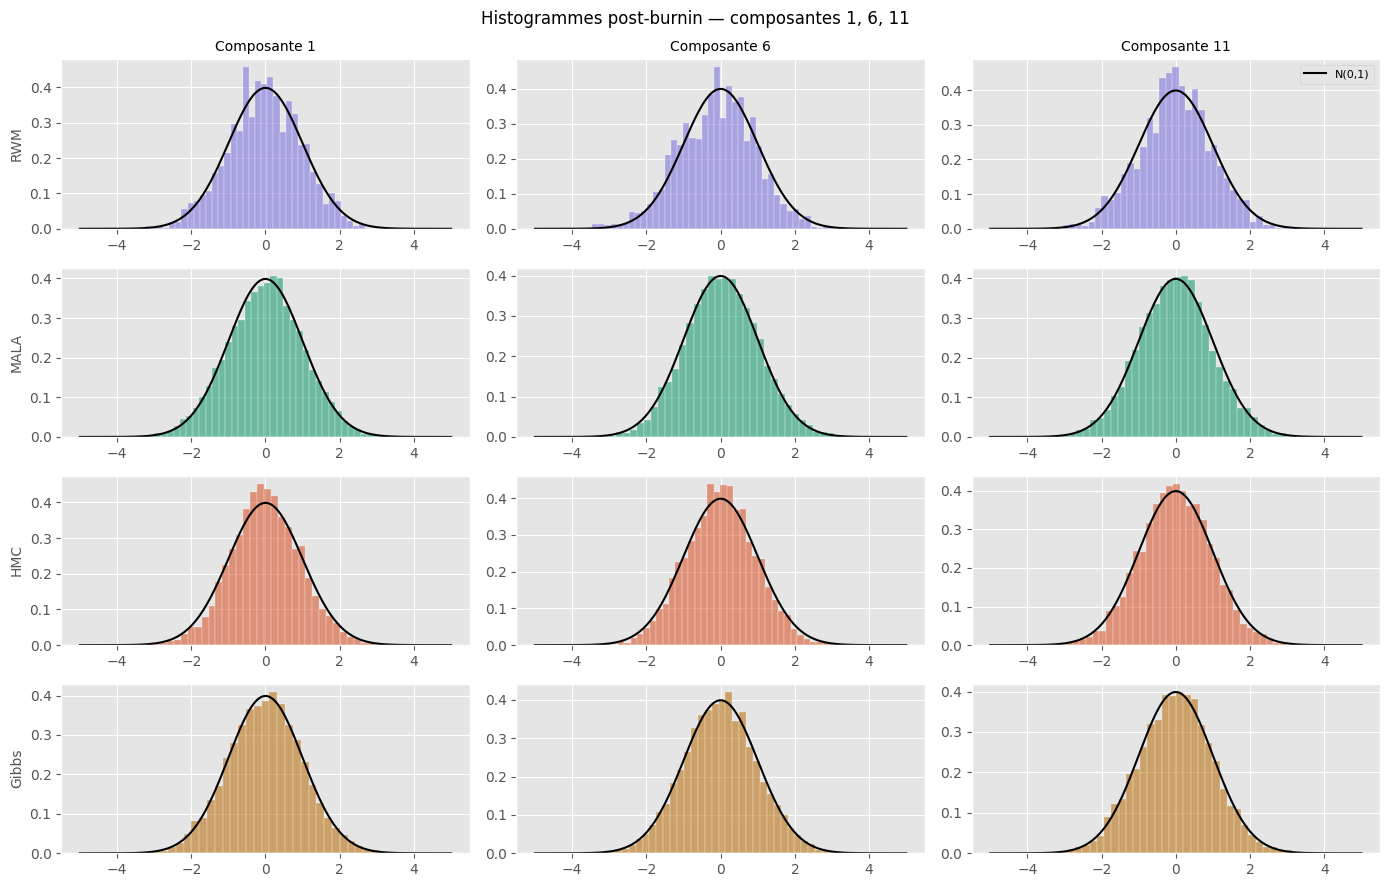

In [13]:
# ── 5.4 Histogrammes post-burnin vs cible N(0,1) ────────────────────────────
xx = np.linspace(-5, 5, 200)

fig, axes = plt.subplots(4, 3, figsize=(14, 9))
fig.suptitle('Histogrammes post-burnin — composantes 1, 6, 11', fontsize=12)

for row, (name, color) in enumerate(zip(names, colors)):
    post = traces[name][BURNIN:]
    for col, j in enumerate([0, 5, 10]):
        ax = axes[row, col]
        ax.hist(post[:, j], bins=40, density=True,
                color=color, alpha=0.6, edgecolor='white', linewidth=0.3)
        ax.plot(xx, stats.norm.pdf(xx), 'k-', lw=1.5, label='N(0,1)')
        if col == 0:
            ax.set_ylabel(name, fontsize=10)
        if row == 0:
            ax.set_title(f'Composante {j+1}', fontsize=10)
        if row == 0 and col == 2:
            ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('histograms.png', dpi=150, bbox_inches='tight')
plt.show()


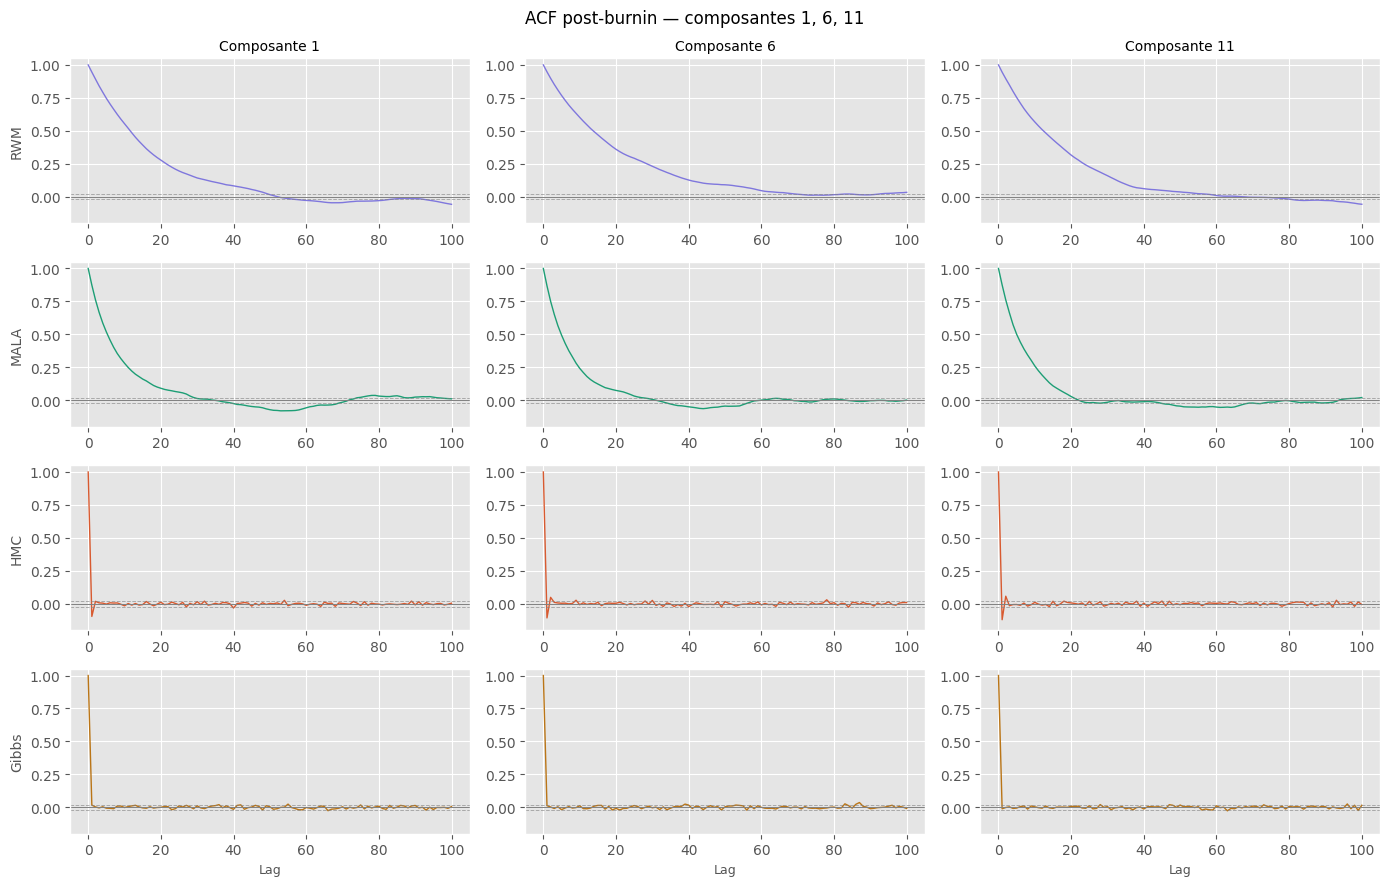

In [14]:
# ── 5.5 ACF — décroissance de l'autocorrélation ─────────────────────────────
fig, axes = plt.subplots(4, 3, figsize=(14, 9))
fig.suptitle('ACF post-burnin — composantes 1, 6, 11', fontsize=12)

for row, (name, color) in enumerate(zip(names, colors)):
    post = traces[name][BURNIN:]
    for col, j in enumerate([0, 5, 10]):
        ax = axes[row, col]
        acf = sm.tsa.acf(post[:, j], nlags=100, fft=True)
        ax.plot(acf, color=color, lw=1)
        ax.axhline(0, color='gray', lw=0.7)
        ax.axhline(1.96/np.sqrt(len(post)), color='gray', ls='--', lw=0.7, alpha=0.6)
        ax.axhline(-1.96/np.sqrt(len(post)), color='gray', ls='--', lw=0.7, alpha=0.6)
        ax.set_ylim(-0.2, 1.05)
        if col == 0:
            ax.set_ylabel(name, fontsize=10)
        if row == 0:
            ax.set_title(f'Composante {j+1}', fontsize=10)
        if row == 3:
            ax.set_xlabel('Lag', fontsize=9)

plt.tight_layout()
plt.savefig('acf_plots.png', dpi=150, bbox_inches='tight')
plt.show()


## 6 · Tableau récapitulatif & interprétation

In [15]:
print("=" * 68)
print(f"{'Algorithme':<10} {'CPU (s)':>12} {'Inf. error':>14} {'MC error':>14} {'Acc. rate':>10}")
print("─" * 68)
for name in names:
    r = results[name]
    print(f"{name:<10} "
          f"{np.mean(r['cpu']):>8.3f}±{np.std(r['cpu']):.3f}  "
          f"{np.mean(r['inf_err']):>8.4f}±{np.std(r['inf_err']):.4f}  "
          f"{np.mean(r['mc_err']):>8.4f}±{np.std(r['mc_err']):.4f}  "
          f"{np.mean(r['acc']):>9.1%}")
print("=" * 68)

print("""
Lecture rapide :
  • RWM   : référence. Correct mais autocorrélation élevée → ESS faible.
  • MALA  : gradient réduit l'autocorrélation → meilleur MC error à CPU comparable.
  • HMC   : meilleur mix (ESS élevé) mais coût par itération plus élevé (L leapfrog steps).
  • Gibbs : tirage exact ici (conditionnelles N(0,1)) → très faible MC error, très rapide.
            (Avantage disparaît pour des cibles non-séparables.)
""")


Algorithme      CPU (s)     Inf. error       MC error  Acc. rate
────────────────────────────────────────────────────────────────────
RWM           0.153±0.024    0.0515±0.0102    0.0623±0.0016      22.0%
MALA          0.293±0.020    0.0287±0.0050    0.0412±0.0008      95.9%
HMC           0.635±0.030    0.0067±0.0012    0.0099±0.0000      70.6%
Gibbs         0.087±0.011    0.0080±0.0018    0.0106±0.0001     100.0%

Lecture rapide :
  • RWM   : référence. Correct mais autocorrélation élevée → ESS faible.
  • MALA  : gradient réduit l'autocorrélation → meilleur MC error à CPU comparable.
  • HMC   : meilleur mix (ESS élevé) mais coût par itération plus élevé (L leapfrog steps).
  • Gibbs : tirage exact ici (conditionnelles N(0,1)) → très faible MC error, très rapide.
            (Avantage disparaît pour des cibles non-séparables.)



---
## 7 · Analyse approfondie du RWM — étude des paramètres

Cette section isole l'algorithme RWM et explore systématiquement l'effet de chaque
paramètre sur les trois métriques de qualité.

| Paramètre | Rôle | Valeur de référence |
|---|---|---|
| `sigma` | Écart-type de la proposition | 0.8 |
| `d` | Dimension de l'espace | 11 |
| `N` | Longueur de la chaîne | 10 000 |
| `x0_scale` | Échelle du point de départ | 50 (linspace) |

> **Règle d'or** : le taux d'acceptation optimal pour RWM en dimension d est ≈ 0.234 (théorème de Roberts & Rosenthal 1997).  
> Le sigma optimal vaut approximativement **2.38 / √d**.


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# Helpers réutilisables pour l'analyse RWM
# ─────────────────────────────────────────────────────────────────────────────

def run_rwm_full(N, d, sigma=0.8, x0_scale=50, seed=None):
    """
    RWM générique.
    Retourne (chain, acceptance_rate, cpu_time_s).
    x0_scale : les composantes initiales sont linspace(-x0_scale, x0_scale, d).
    """
    if seed is not None:
        np.random.seed(seed)
    x0 = np.linspace(-x0_scale, x0_scale, d)
    chain = np.empty((N, d))
    chain[0] = x0
    acc = 0
    t0 = time.perf_counter()
    for n in range(1, N):
        prop = chain[n - 1] + sigma * np.random.randn(d)
        if np.log(np.random.rand()) < log_target(prop) - log_target(chain[n - 1]):
            chain[n] = prop
            acc += 1
        else:
            chain[n] = chain[n - 1]
    cpu = time.perf_counter() - t0
    return chain, acc / N, cpu


def metrics_rwm(chain, burnin=BURNIN):
    """Calcule les 3 métriques sur la partie post-burnin."""
    post = chain[burnin:]
    ie   = inferential_error(post)
    mce  = mc_error(post)
    return ie, mce


def sweep(param_name, param_values, fixed, n_rep=5):
    """
    Lance un sweep sur un paramètre unique.
    fixed : dict des autres paramètres (N, d, sigma, x0_scale).
    Retourne un dict param_val -> dict de listes de métriques.
    """
    results_sw = {}
    for val in param_values:
        kw = dict(fixed)
        kw[param_name] = val
        rows = {'cpu': [], 'inf_err': [], 'mc_err': [], 'acc': []}
        for rep in range(n_rep):
            chain, acc, cpu = run_rwm_full(seed=rep, **kw)
            ie, mce = metrics_rwm(chain, burnin=min(kw['N']//10, BURNIN))
            rows['cpu'].append(cpu)
            rows['inf_err'].append(ie)
            rows['mc_err'].append(mce)
            rows['acc'].append(acc)
        results_sw[val] = rows
    return results_sw


def plot_sweep(results_sw, param_values, param_label, axes_row, color='#7F77DD'):
    """
    Trace les 4 métriques (cpu, acc, inf_err, mc_err) pour un sweep donné.
    axes_row : liste de 4 axes matplotlib.
    """
    metric_keys   = ['cpu',    'acc',         'inf_err',          'mc_err']
    metric_labels = ['CPU time (s)', 'Acceptance rate', 'Inferential error', 'Monte Carlo error']

    for ax, key, label in zip(axes_row, metric_keys, metric_labels):
        means = [np.mean(results_sw[v][key]) for v in param_values]
        stds  = [np.std(results_sw[v][key])  for v in param_values]
        ax.plot(param_values, means, 'o-', color=color, lw=1.8, ms=5)
        ax.fill_between(param_values,
                        np.array(means) - np.array(stds),
                        np.array(means) + np.array(stds),
                        color=color, alpha=0.15)
        ax.set_xlabel(param_label, fontsize=9)
        ax.set_ylabel(label, fontsize=9)
        ax.set_title(label, fontsize=10)
        # ligne de référence acceptance rate optimal
        if key == 'acc':
            ax.axhline(0.234, color='gray', ls='--', lw=1, alpha=0.7,
                       label='optimal 0.234')
            ax.legend(fontsize=8)

print("Helpers chargés.")


Helpers chargés.


### 7.1 · Effet de σ (écart-type de la proposition)

σ trop petit → petits pas → forte autocorrélation → ESS faible.  
σ trop grand → propositions lointaines → beaucoup de rejets → chaîne bloquée.  
La valeur **σ* ≈ 2.38/√d** minimise théoriquement l'erreur MC.


σ optimal théorique ≈ 0.718


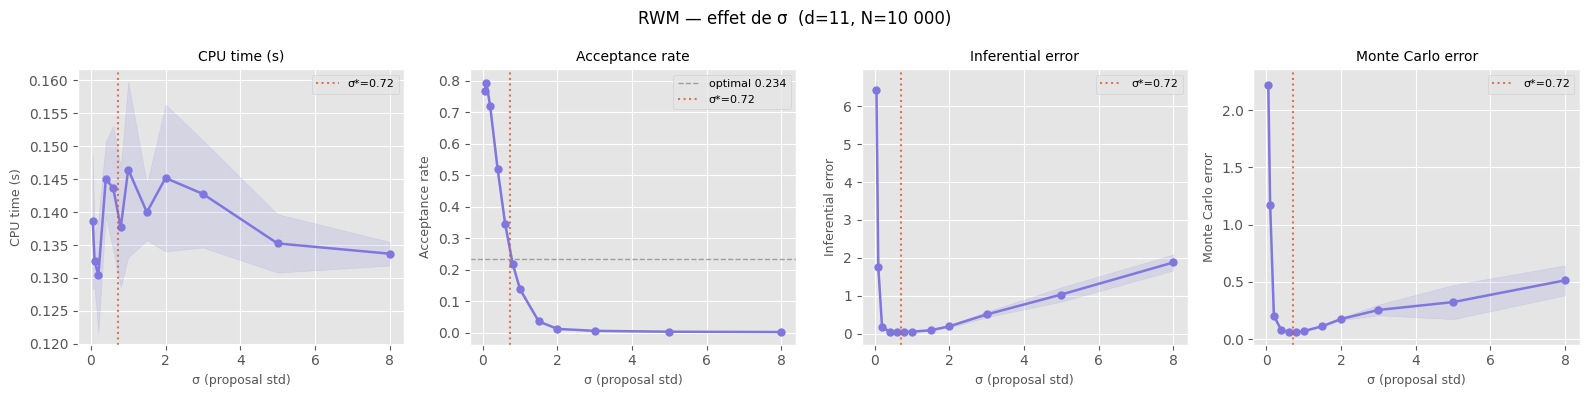


     σ    CPU(s)      Acc.     Inf.err      MC err
──────────────────────────────────────────────────
  0.05     0.139    76.75%      6.4225      2.2212
  0.10     0.133    79.21%      1.7541      1.1732
  0.20     0.130    71.86%      0.1857      0.2032
  0.40     0.145    51.89%      0.0574      0.0762
  0.60     0.144    34.66%      0.0587      0.0644
  0.80     0.138    22.04%      0.0575      0.0617
  1.00     0.146    13.82%      0.0586      0.0698
  1.50     0.140     3.68%      0.0944      0.1124
  2.00     0.145     1.30%      0.1993      0.1758
  3.00     0.143     0.68%      0.5106      0.2544
  5.00     0.135     0.40%      1.0364      0.3231
  8.00     0.134     0.30%      1.8812      0.5132


In [17]:
# ── Paramètres du sweep ───────────────────────────────────────────────────────
SIGMA_VALUES = [0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.5, 2.0, 3.0, 5.0, 8.0]
FIXED_SIGMA  = dict(N=10_000, d=11, x0_scale=50)

sigma_optimal = 2.38 / np.sqrt(FIXED_SIGMA['d'])
print(f"σ optimal théorique ≈ {sigma_optimal:.3f}")

sw_sigma = sweep('sigma', SIGMA_VALUES, FIXED_SIGMA, n_rep=5)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('RWM — effet de σ  (d=11, N=10 000)', fontsize=12)
plot_sweep(sw_sigma, SIGMA_VALUES, 'σ (proposal std)', axes, color='#7F77DD')

# Marquer le sigma optimal théorique sur chaque axe
for ax in axes:
    ax.axvline(sigma_optimal, color='#D85A30', ls=':', lw=1.5, alpha=0.8,
               label=f'σ*={sigma_optimal:.2f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('rwm_sweep_sigma.png', dpi=150, bbox_inches='tight')
plt.show()

# Résumé tabulaire
print(f"\n{'σ':>6}  {'CPU(s)':>8}  {'Acc.':>8}  {'Inf.err':>10}  {'MC err':>10}")
print("─" * 50)
for v in SIGMA_VALUES:
    r = sw_sigma[v]
    print(f"{v:>6.2f}  {np.mean(r['cpu']):>8.3f}  {np.mean(r['acc']):>8.2%}"
          f"  {np.mean(r['inf_err']):>10.4f}  {np.mean(r['mc_err']):>10.4f}")


### 7.2 · Effet de la dimension d

En augmentant d à σ fixé, le taux d'acceptation s'effondre car la norme de la
proposition croît en √d. Il faut rescaler σ ∝ 1/√d pour maintenir le taux optimal.


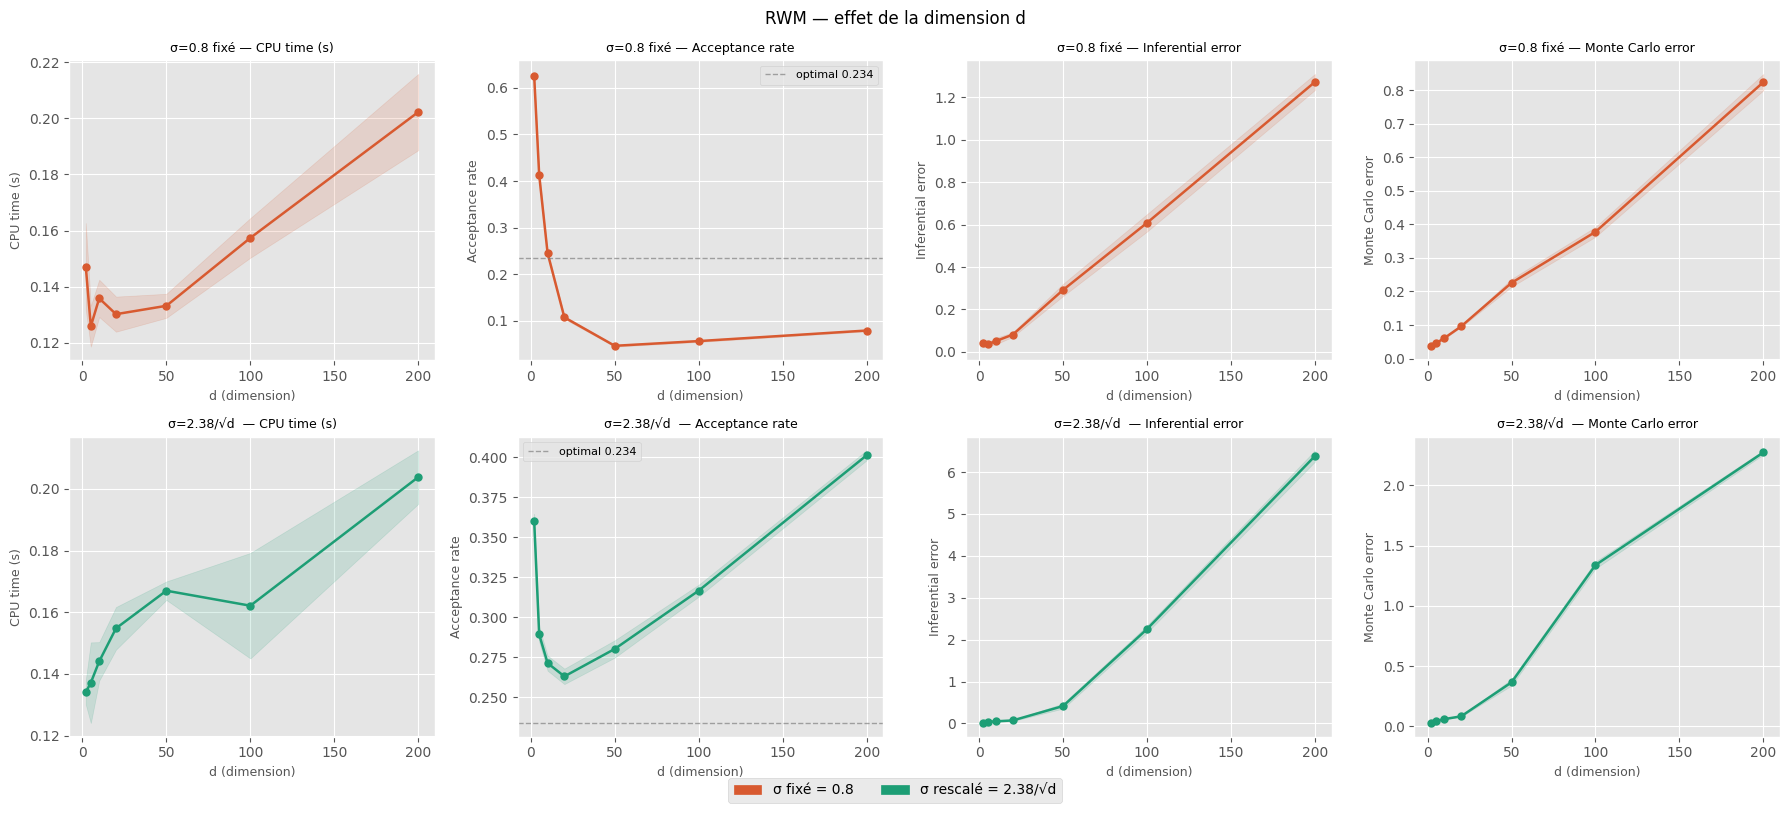

In [18]:
DIM_VALUES  = [2, 5, 10, 20, 50, 100, 200]
FIXED_DIM   = dict(N=10_000, sigma=0.8, x0_scale=50)

sw_dim_fixed  = sweep('d', DIM_VALUES, FIXED_DIM, n_rep=5)

# Sweep avec sigma rescalé : sigma = 2.38 / sqrt(d)
sw_dim_scaled = {}
for dim in DIM_VALUES:
    kw = dict(FIXED_DIM, d=dim, sigma=2.38/np.sqrt(dim))
    rows = {'cpu': [], 'inf_err': [], 'mc_err': [], 'acc': []}
    for rep in range(5):
        chain, acc, cpu = run_rwm_full(seed=rep, **kw)
        ie, mce = metrics_rwm(chain, burnin=min(kw['N']//10, BURNIN))
        rows['cpu'].append(cpu); rows['inf_err'].append(ie)
        rows['mc_err'].append(mce); rows['acc'].append(acc)
    sw_dim_scaled[dim] = rows

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('RWM — effet de la dimension d', fontsize=12)

plot_sweep(sw_dim_fixed,  DIM_VALUES, 'd (dimension)', axes[0], color='#D85A30')
plot_sweep(sw_dim_scaled, DIM_VALUES, 'd (dimension)', axes[1], color='#1D9E75')

for ax in axes[0]: ax.set_title('σ=0.8 fixé — ' + ax.get_title(), fontsize=9)
for ax in axes[1]: ax.set_title('σ=2.38/√d  — ' + ax.get_title(), fontsize=9)

# Légende globale
from matplotlib.patches import Patch
handles = [Patch(color='#D85A30', label='σ fixé = 0.8'),
           Patch(color='#1D9E75', label='σ rescalé = 2.38/√d')]
fig.legend(handles=handles, loc='lower center', ncol=2,
           fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig('rwm_sweep_dim.png', dpi=150, bbox_inches='tight')
plt.show()


### 7.3 · Effet de la longueur de chaîne N

L'erreur MC décroît en O(1/√ESS) ≈ O(1/√N). On vérifie ici empiriquement
cette loi et on identifie le N à partir duquel les gains sont marginaux.


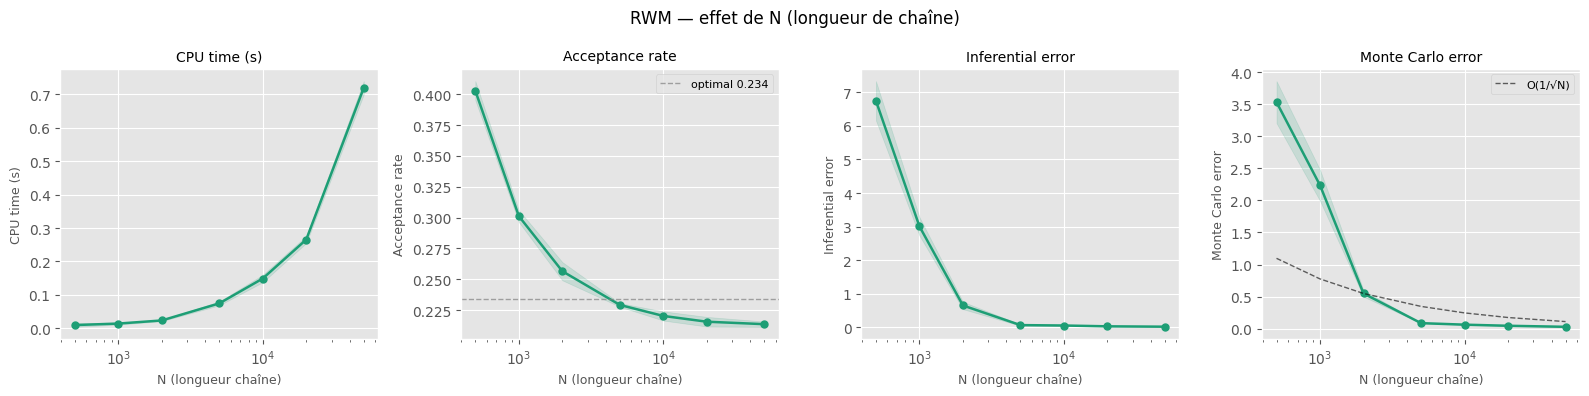

In [19]:
N_VALUES   = [500, 1_000, 2_000, 5_000, 10_000, 20_000, 50_000]
FIXED_N    = dict(d=11, sigma=0.8, x0_scale=50)

sw_N = {}
for n_val in N_VALUES:
    kw    = dict(FIXED_N, N=n_val)
    bi    = max(100, n_val // 10)
    rows  = {'cpu': [], 'inf_err': [], 'mc_err': [], 'acc': []}
    for rep in range(5):
        chain, acc, cpu = run_rwm_full(seed=rep, **kw)
        post = chain[bi:]
        rows['cpu'].append(cpu)
        rows['acc'].append(acc)
        rows['inf_err'].append(inferential_error(post))
        rows['mc_err'].append(mc_error(post))
    sw_N[n_val] = rows

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('RWM — effet de N (longueur de chaîne)', fontsize=12)
plot_sweep(sw_N, N_VALUES, 'N (longueur chaîne)', axes, color='#1D9E75')

# Courbe théorique 1/sqrt(N) pour MC error
mc_ref_N = N_VALUES[2]
mc_ref_v = np.mean(sw_N[mc_ref_N]['mc_err'])
theory   = [mc_ref_v * np.sqrt(mc_ref_N / n) for n in N_VALUES]
axes[3].plot(N_VALUES, theory, 'k--', lw=1, alpha=0.6, label='O(1/√N)')
axes[3].legend(fontsize=8)

for ax in axes:
    ax.set_xscale('log')

plt.tight_layout()
plt.savefig('rwm_sweep_N.png', dpi=150, bbox_inches='tight')
plt.show()


### 7.4 · Effet du point de départ x₀ (sensibilité au burn-in)

Un point de départ très éloigné de la masse de la cible allonge la phase de
*burn-in*. On mesure ici à quel point le choix de x₀ dégrade les métriques
si on sous-estime le burn-in.


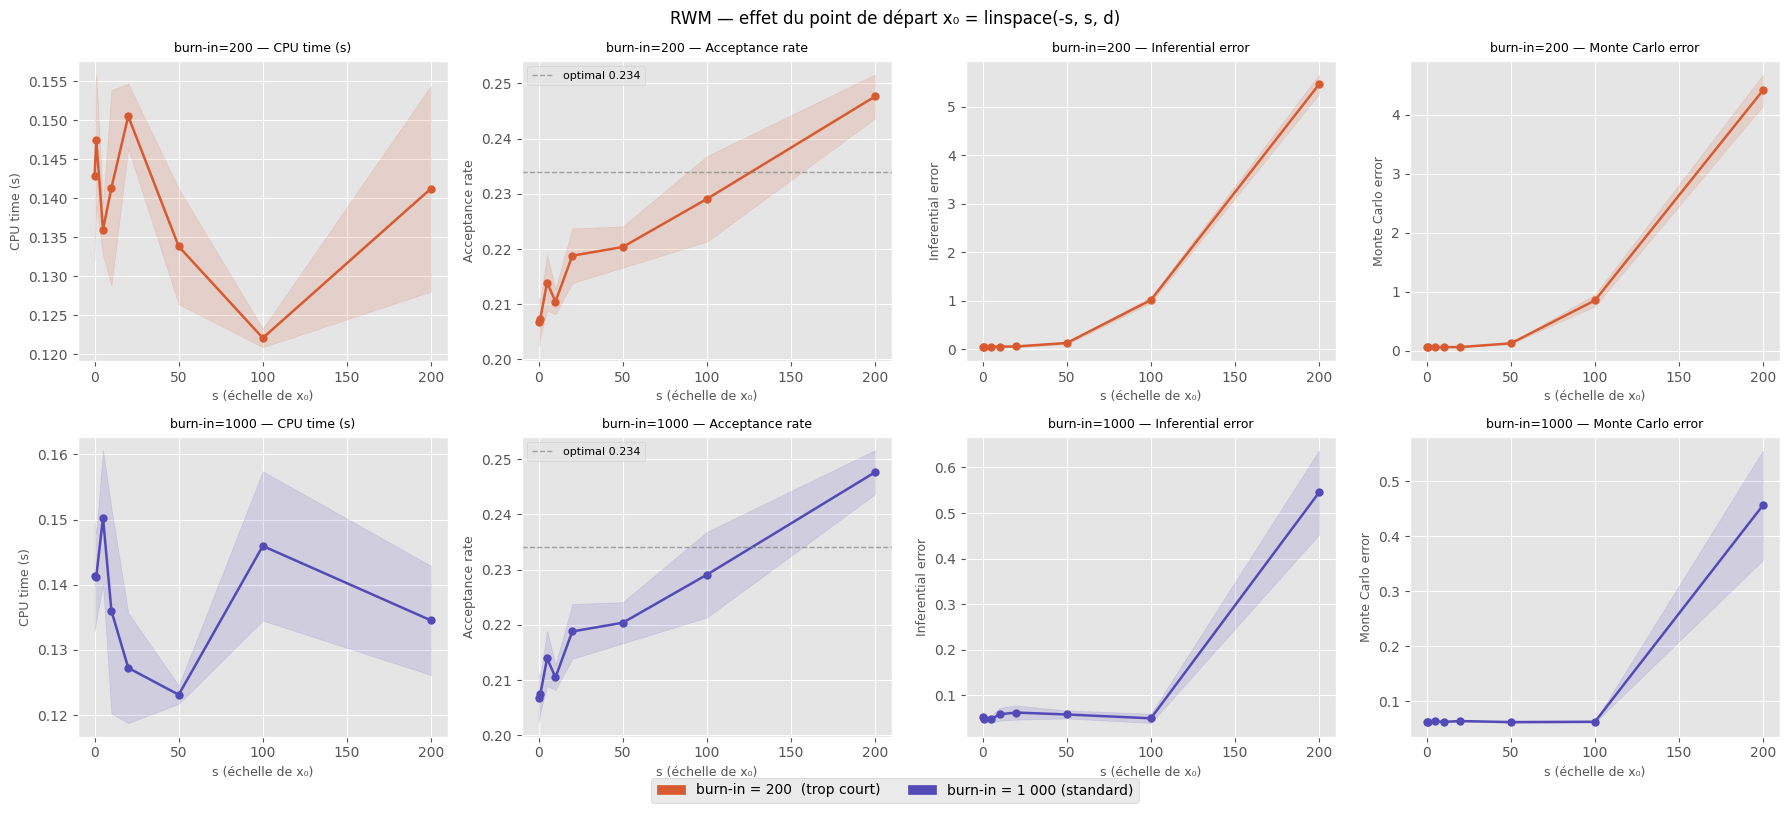

In [20]:
X0_VALUES  = [0, 1, 5, 10, 20, 50, 100, 200]   # x0 = linspace(-scale, scale, d)
FIXED_X0   = dict(N=10_000, d=11, sigma=0.8)

# On teste avec deux burn-ins : petit (200) et standard (1000)
sw_x0_short  = {}   # burnin = 200
sw_x0_normal = {}   # burnin = 1000

for scale in X0_VALUES:
    kw = dict(FIXED_X0, x0_scale=scale)
    for sw, bi in [(sw_x0_short, 200), (sw_x0_normal, 1000)]:
        rows = {'cpu': [], 'inf_err': [], 'mc_err': [], 'acc': []}
        for rep in range(5):
            chain, acc, cpu = run_rwm_full(seed=rep, **kw)
            post = chain[bi:]
            rows['cpu'].append(cpu)
            rows['acc'].append(acc)
            rows['inf_err'].append(inferential_error(post))
            rows['mc_err'].append(mc_error(post))
        sw[scale] = rows

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('RWM — effet du point de départ x₀ = linspace(-s, s, d)', fontsize=12)

plot_sweep(sw_x0_short,  X0_VALUES, 's (échelle de x₀)', axes[0], color='#D85A30')
plot_sweep(sw_x0_normal, X0_VALUES, 's (échelle de x₀)', axes[1], color='#534AB7')

for ax in axes[0]: ax.set_title('burn-in=200 — ' + ax.get_title(), fontsize=9)
for ax in axes[1]: ax.set_title('burn-in=1000 — ' + ax.get_title(), fontsize=9)

from matplotlib.patches import Patch
handles = [Patch(color='#D85A30', label='burn-in = 200  (trop court)'),
           Patch(color='#534AB7', label='burn-in = 1 000 (standard)')]
fig.legend(handles=handles, loc='lower center', ncol=2,
           fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig('rwm_sweep_x0.png', dpi=150, bbox_inches='tight')
plt.show()


### 7.5 · Heatmap σ × d — taux d'acceptation et erreur MC

Vue 2D des interactions entre σ et d. Chaque cellule est la moyenne sur 3 répétitions.


Construction de la heatmap ...
  d=2 ✓
  d=5 ✓
  d=11 ✓
  d=20 ✓
  d=50 ✓
  d=100 ✓


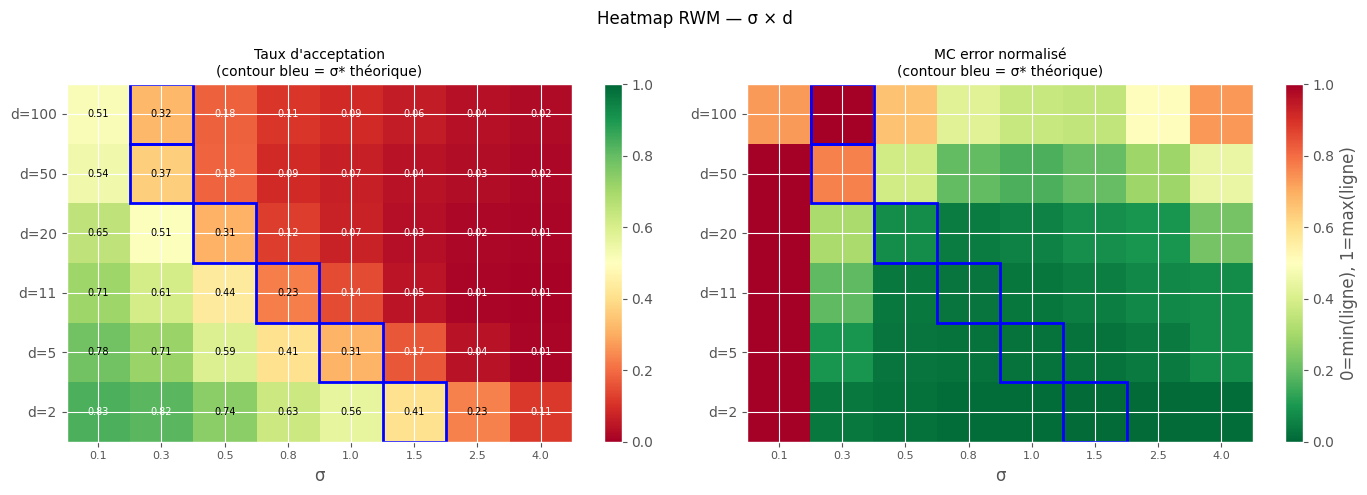

In [21]:
SIGMAS_HM = [0.1, 0.3, 0.5, 0.8, 1.0, 1.5, 2.5, 4.0]
DIMS_HM   = [2, 5, 11, 20, 50, 100]
N_HM      = 5_000

acc_matrix = np.zeros((len(DIMS_HM), len(SIGMAS_HM)))
mce_matrix = np.zeros((len(DIMS_HM), len(SIGMAS_HM)))

print("Construction de la heatmap ...")
for i, dim in enumerate(DIMS_HM):
    for j, sig in enumerate(SIGMAS_HM):
        accs, mces = [], []
        for rep in range(3):
            chain, acc, _ = run_rwm_full(N=N_HM, d=dim, sigma=sig,
                                         x0_scale=50, seed=rep)
            accs.append(acc)
            mces.append(mc_error(chain[N_HM//10:]))
        acc_matrix[i, j] = np.mean(accs)
        mce_matrix[i, j] = np.mean(mces)
    print(f"  d={dim} ✓")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Heatmap RWM — σ × d', fontsize=12)

import matplotlib.colors as mcolors

im1 = ax1.imshow(acc_matrix, aspect='auto', cmap='RdYlGn',
                  vmin=0, vmax=1, origin='lower')
ax1.set_xticks(range(len(SIGMAS_HM))); ax1.set_xticklabels([f'{s}' for s in SIGMAS_HM], fontsize=8)
ax1.set_yticks(range(len(DIMS_HM)));   ax1.set_yticklabels([f'd={d}' for d in DIMS_HM])
ax1.set_xlabel('σ'); ax1.set_title("Taux d'acceptation")
plt.colorbar(im1, ax=ax1)
for i in range(len(DIMS_HM)):
    for j in range(len(SIGMAS_HM)):
        ax1.text(j, i, f'{acc_matrix[i,j]:.2f}', ha='center', va='center', fontsize=7,
                 color='black' if 0.2 < acc_matrix[i,j] < 0.8 else 'white')

# Pour MC error : normaliser par ligne pour voir le minimum
mce_norm = mce_matrix / (mce_matrix.max(axis=1, keepdims=True) + 1e-12)
im2 = ax2.imshow(mce_norm, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=1, origin='lower')
ax2.set_xticks(range(len(SIGMAS_HM))); ax2.set_xticklabels([f'{s}' for s in SIGMAS_HM], fontsize=8)
ax2.set_yticks(range(len(DIMS_HM)));   ax2.set_yticklabels([f'd={d}' for d in DIMS_HM])
ax2.set_xlabel('σ'); ax2.set_title('Monte Carlo error (normalisé par ligne)')
plt.colorbar(im2, ax=ax2, label='0=min(ligne), 1=max(ligne)')

# Marquer le sigma optimal théorique
for i, dim in enumerate(DIMS_HM):
    sig_opt = 2.38 / np.sqrt(dim)
    j_closest = np.argmin(np.abs(np.array(SIGMAS_HM) - sig_opt))
    for ax in (ax1, ax2):
        ax.add_patch(plt.Rectangle((j_closest-0.5, i-0.5), 1, 1,
                                   fill=False, edgecolor='blue', lw=2))

ax1.set_title("Taux d'acceptation\n(contour bleu = σ* théorique)", fontsize=10)
ax2.set_title('MC error normalisé\n(contour bleu = σ* théorique)', fontsize=10)

plt.tight_layout()
plt.savefig('rwm_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


### 7.6 · Diagnostic de convergence : R̂ de Gelman-Rubin

Le **R̂** (Gelman-Rubin) compare la variance *entre* plusieurs chaînes à la
variance *intra-chaîne*. R̂ ≈ 1 indique la convergence ; R̂ > 1.1 signale un
problème.

On lance **M chaînes parallèles** avec des x₀ différents et on calcule R̂ pour
différentes valeurs de σ.


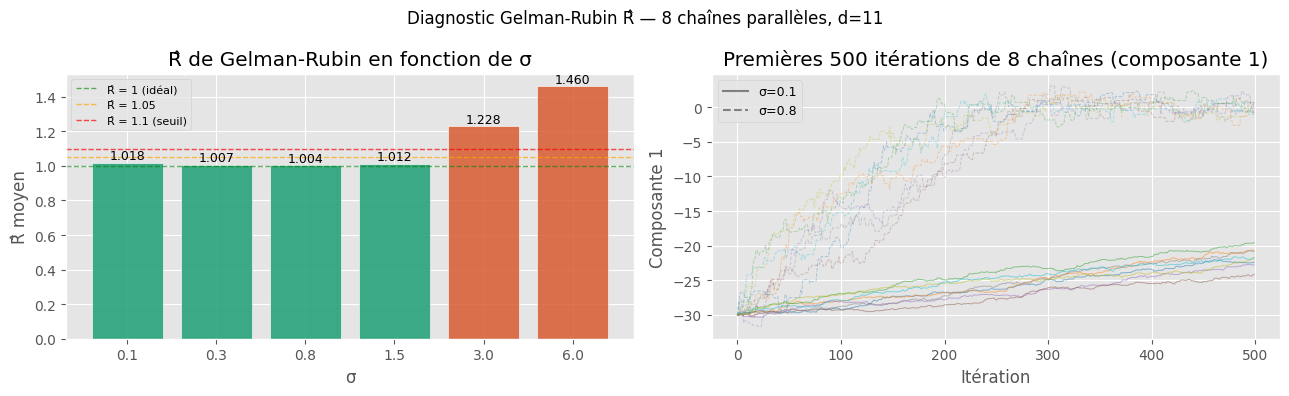


Résumé R̂ :
  σ=0.1    R̂=1.0175  ✓ convergé
  σ=0.3    R̂=1.0073  ✓ convergé
  σ=0.8    R̂=1.0041  ✓ convergé
  σ=1.5    R̂=1.0121  ✓ convergé
  σ=3.0    R̂=1.2284  ✗ non convergé
  σ=6.0    R̂=1.4600  ✗ non convergé


In [22]:
def gelman_rubin(chains):
    """
    chains : array (M, N, d)  — M chaînes indépendantes de longueur N en dim d.
    Retourne R_hat moyen sur les d composantes.
    """
    M, N, d = chains.shape
    # Moyennes intra-chaîne
    theta_bar_j = chains.mean(axis=1)          # (M, d)
    theta_bar   = theta_bar_j.mean(axis=0)     # (d,)
    # Variance entre chaînes B
    B = N / (M - 1) * np.sum((theta_bar_j - theta_bar)**2, axis=0)  # (d,)
    # Variance intra-chaîne W
    s2_j = chains.var(axis=1, ddof=1)          # (M, d)
    W    = s2_j.mean(axis=0)                   # (d,)
    # Estimateur de la variance marginale
    var_plus = (N - 1) / N * W + B / N
    Rhat = np.sqrt(var_plus / np.clip(W, 1e-12, None))
    return float(np.mean(Rhat))


SIGMAS_GR = [0.1, 0.3, 0.8, 1.5, 3.0, 6.0]
M_CHAINS  = 8
N_GR      = 5_000
BI_GR     = 500
D_GR      = 11

rhat_results = {}
for sig in SIGMAS_GR:
    # x0 aléatoires très dispersés
    all_chains = []
    for m in range(M_CHAINS):
        np.random.seed(m * 13)
        x0_scale = 30
        chain, _, _ = run_rwm_full(N=N_GR, d=D_GR, sigma=sig,
                                   x0_scale=x0_scale, seed=m)
        all_chains.append(chain[BI_GR:])
    chains_arr = np.array(all_chains)   # (M, N-BI, d)
    rhat_results[sig] = gelman_rubin(chains_arr)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Diagnostic Gelman-Rubin R̂ — {M_CHAINS} chaînes parallèles, d={D_GR}', fontsize=12)

# R̂ vs sigma
ax = axes[0]
rhat_vals = [rhat_results[s] for s in SIGMAS_GR]
bars = ax.bar([str(s) for s in SIGMAS_GR], rhat_vals,
              color=['#1D9E75' if v < 1.05 else '#D85A30' if v > 1.1 else '#BA7517'
                     for v in rhat_vals], alpha=0.85, edgecolor='white')
ax.axhline(1.0,  color='green', lw=1, ls='--', alpha=0.6, label='R̂ = 1 (idéal)')
ax.axhline(1.05, color='orange', lw=1, ls='--', alpha=0.7, label='R̂ = 1.05')
ax.axhline(1.1,  color='red',   lw=1, ls='--', alpha=0.7, label='R̂ = 1.1 (seuil)')
for bar, v in zip(bars, rhat_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{v:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xlabel('σ'); ax.set_ylabel('R̂ moyen')
ax.set_title('R̂ de Gelman-Rubin en fonction de σ')
ax.legend(fontsize=8)

# Trace des M chaînes pour sigma = 0.1 (mauvais) et sigma = 0.8 (bon)
ax2 = axes[1]
colors_chains = plt.cm.tab10(np.linspace(0, 1, M_CHAINS))
for sig_show, ls, lbl in [(0.1, '-', 'σ=0.1 (R̂=%.3f)' % rhat_results[0.1]),
                           (0.8, '--', 'σ=0.8 (R̂=%.3f)' % rhat_results[0.8])]:
    for m in range(M_CHAINS):
        np.random.seed(m * 13)
        chain, _, _ = run_rwm_full(N=N_GR, d=D_GR, sigma=sig_show, x0_scale=30, seed=m)
        alpha = 0.5 if sig_show == 0.1 else 0.3
        ax2.plot(chain[:500, 0], lw=0.7, ls=ls, alpha=alpha,
                 color=colors_chains[m])

from matplotlib.lines import Line2D
leg_handles = [Line2D([0],[0], ls='-',  color='gray', lw=1.5, label='σ=0.1'),
               Line2D([0],[0], ls='--', color='gray', lw=1.5, label='σ=0.8')]
ax2.legend(handles=leg_handles, fontsize=9)
ax2.set_xlabel('Itération'); ax2.set_ylabel('Composante 1')
ax2.set_title(f'Premières 500 itérations de {M_CHAINS} chaînes (composante 1)')

plt.tight_layout()
plt.savefig('rwm_gelman_rubin.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nRésumé R̂ :")
for s, v in rhat_results.items():
    flag = "✓ convergé" if v < 1.05 else ("⚠ limite" if v < 1.1 else "✗ non convergé")
    print(f"  σ={s:<5}  R̂={v:.4f}  {flag}")


### 7.7 · Résumé des recommandations pour RWM

| Paramètre | Recommandation | Pourquoi |
|---|---|---|
| **σ** | `2.38 / √d` | Minimise le MC error, acc ≈ 23% |
| **d** | Rescaler σ si d change | Acceptance ∝ 1/√d à σ fixé |
| **N** | ≥ 10 × ESS effectif | MC error ∝ 1/√ESS |
| **burn-in** | ≥ 10% de N, adapté à x₀ | Élimine la phase transitoire |
| **R̂** | < 1.05 sur M ≥ 4 chaînes | Valide la convergence |


